In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

/home/lucifer666/anaconda3/envs/py312/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
2026-07-26 16:17:52.754804: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
data = pd.read_csv('data/AABA_2006-01-01_to_2018-01-01.csv')
data.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
1,2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2,2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
3,2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
4,2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3019 entries, 0 to 3018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3019 non-null   object 
 1   Open    3019 non-null   float64
 2   High    3019 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3019 non-null   float64
 5   Volume  3019 non-null   int64  
 6   Name    3019 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 165.2+ KB


In [4]:
df = data[['Open']]
df.head()

,Open
0,39.69
1,41.22
2,40.93
3,42.88
4,43.10


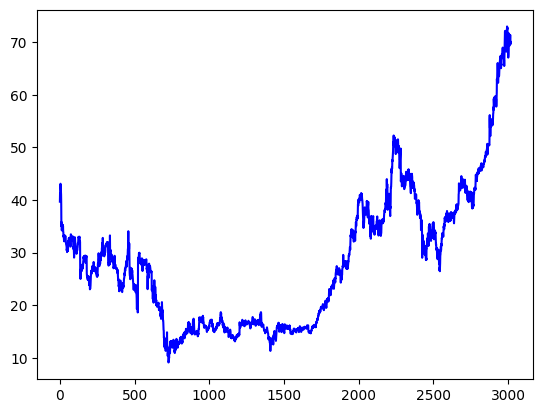

In [5]:
plt.plot(data['Open'], color='blue')

In [6]:
X = data['Open'].values

In [7]:
X[:10]

array([39.69, 41.22, 40.93, 42.88, 43.1 , 42.96, 42.19, 41.92, 41.  ,
       39.09])

In [8]:
X_train, X_test = X[:2500], X[2500:]

In [9]:
model = Sequential([
    SimpleRNN(64, activation='tanh'),
    Dense(1)
])

2026-07-26 16:19:16.516003: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.compile(optimizer='adam', loss='mean_absolute_error')

In [11]:
XT, yT = [], []
for i in range(len(X_train) - 90):
    d = i + 90
    XT.append(X_train[i:d,])
    yT.append(X_train[d])

In [12]:
Xt, yt = [], []
for i in range(90):
    d = i + 90
    Xt.append(X_test[i:d,])
    yt.append(X_test[d])

In [13]:
XT = np.array(XT)
Xt = np.array(Xt)
yT = np.array(yT)
yt = np.array(yt)

In [14]:
XT.shape, yT.shape

((2410, 90), (2410,))

In [15]:
XT[0], yT[0]

(array([39.69, 41.22, 40.93, 42.88, 43.1 , 42.96, 42.19, 41.92, 41.  ,
        39.09, 35.01, 35.82, 34.44, 34.22, 34.55, 35.43, 34.94, 35.26,
        35.06, 35.2 , 34.45, 35.01, 34.  , 33.9 , 33.01, 33.24, 33.01,
        32.58, 32.21, 32.14, 32.62, 33.3 , 32.88, 32.9 , 32.49, 33.01,
        33.2 , 33.11, 32.63, 32.21, 32.01, 31.7 , 31.53, 31.42, 31.31,
        31.05, 30.4 , 30.72, 30.1 , 31.25, 30.77, 30.34, 30.38, 30.42,
        30.33, 31.52, 32.28, 31.84, 31.45, 32.44, 32.75, 32.45, 32.41,
        31.69, 32.3 , 32.12, 32.85, 32.28, 32.45, 31.44, 31.14, 31.16,
        31.17, 33.47, 33.48, 33.36, 33.01, 32.99, 32.3 , 32.79, 32.88,
        32.99, 32.2 , 32.4 , 32.4 , 32.63, 33.09, 32.68, 32.48, 31.96]),
 np.float64(30.71))

In [16]:
XT = XT.reshape((XT.shape[0], XT.shape[1], 1))
Xt = Xt.reshape((Xt.shape[0], Xt.shape[1], 1))

In [17]:
XT.shape

(2410, 90, 1)

In [18]:
history = model.fit(XT, yT, batch_size=20, epochs=100)

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 16.0762
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.7245
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5.6936
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 3.4190
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.2929
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.6523
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.2620
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1.0339
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.8692
Epoch 10/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.7607
Epoch 11/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.6739
Epoch 12/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.6126
Epoch 13/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.5776
Epoch 14/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5405
Epoch 15/100
121/121 ━━━━━━━

In [19]:
history.history

{'loss': [16.076183319091797,
  8.724455833435059,
  5.693552494049072,
  3.419001340866089,
  2.2929458618164062,
  1.6523427963256836,
  1.262039065361023,
  1.033902883529663,
  0.8691704273223877,
  0.7606684565544128,
  0.6738652586936951,
  0.6126269102096558,
  0.5775980949401855,
  0.5405223965644836,
  0.5449408888816833,
  0.5254487991333008,
  0.5090847611427307,
  0.5144761204719543,
  0.4909605085849762,
  0.49534085392951965,
  0.4735487401485443,
  0.4704988896846771,
  0.45659443736076355,
  0.46006062626838684,
  0.4383945167064667,
  0.4507649540901184,
  0.43571558594703674,
  0.4404231905937195,
  0.4457789361476898,
  0.43655139207839966,
  0.44060438871383667,
  0.439071923494339,
  0.4248948097229004,
  0.4354623854160309,
  0.43523770570755005,
  0.4200255870819092,
  0.4274996519088745,
  0.4357348382472992,
  0.4295753538608551,
  0.4287548065185547,
  0.43222302198410034,
  0.4341721534729004,
  0.42051663994789124,
  0.423559308052063,
  0.4232490062713623,


In [20]:
model.evaluate(Xt, yt)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4152 


0.4152003526687622

In [21]:
XTpred = model.predict(XT)
Xtpred = model.predict(Xt)
X_pred = np.concatenate([XTpred, Xtpred], axis=0)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


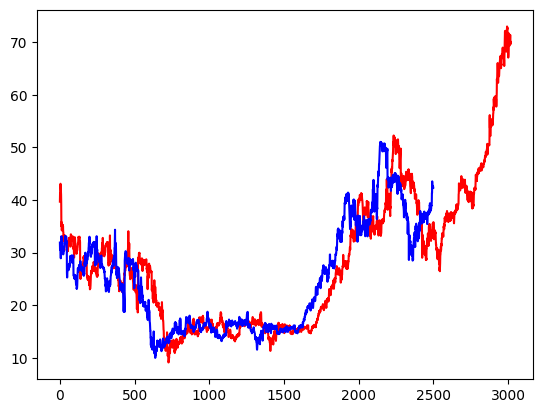

In [22]:
plt.plot(X, color='red')
plt.plot(X_pred, color='blue')

In [23]:
from tensorflow.keras.layers import LSTM, GRU, Dropout

In [24]:
model = Sequential([
    LSTM(units=128, activation='tanh', input_shape=(90, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

/home/lucifer666/anaconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='Adam', loss='mean_absolute_error')

In [30]:
hostoty = model.fit(XT, yT, batch_size=20, epochs=100)

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - loss: 2.6528
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 2.4327
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step - loss: 2.4170
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - loss: 2.4065
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - loss: 2.3222
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - loss: 2.3259
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step - loss: 2.3381
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - loss: 2.2775
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - loss: 2.2257
Epoch 10/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 15s 127ms/step - loss: 2.2788
Epoch 11/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - loss: 2.3211
Epoch 12/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 15s 127ms/step - loss: 2.1858
Epoch 13/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 16s 131ms/step - loss: 2.2229
Epoch 14/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 16s 131ms/step - loss: 2.2811
E

In [31]:
model.evaluate(Xt, yt)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 1.5955


1.595543622970581

In [32]:
XT_pred = model.predict(XT)
Xt_pred = model.predict(Xt)
X_predict = np.concatenate([XT_pred, Xt_pred], axis=0)

76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


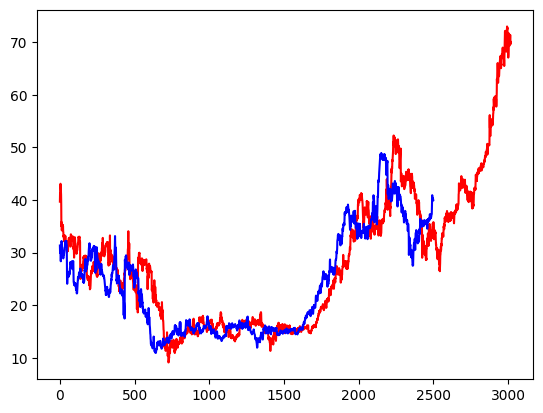

In [34]:
plt.plot(X, color='red')
plt.plot(X_predict, color='blue')